In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

In [3]:
base = pd.read_csv('../data/processed/base_tratada.csv')
base.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,price
0,7420,4,2,3,2,1,0,0,0,1,1,0,0,13300000
1,8960,4,4,4,3,1,0,0,0,1,0,0,0,12250000
2,9960,3,2,2,2,1,0,1,0,0,1,1,0,12250000
3,7500,4,2,2,3,1,0,1,0,1,1,0,0,12215000
4,7420,4,1,2,2,1,1,1,0,1,0,0,0,11410000


In [4]:
# Separar as variaveis
X = base.drop(columns=['price'], axis=1)
y = base['price']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Regressao Linear
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

In [7]:
#Avaliação do modelo de regressão linear
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f'MAE Regressão Linear: {mae_lr}')
print(f'MSE Regressão Linear: {mse_lr}')
print(f'R² Regressão Linear: {r2_lr}')

MAE Regressão Linear: 970043.4039201637
MSE Regressão Linear: 1754318687330.6643
R² Regressão Linear: 0.6529242642153184


In [8]:
# Random Forest Regressor
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)


In [9]:
#Avaliando o modelo de Random Forest Regressor
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f'MAE Random Forest Regressor: {mae_rf}')
print(f'MSE Random Forest Regressor: {mse_rf}')
print(f'R² Random Forest Regressor: {r2_rf}')

MAE Random Forest Regressor: 1021546.0353211008
MSE Random Forest Regressor: 1961585044320.3433
R² Random Forest Regressor: 0.611918531405699


In [10]:
# Comparando os modelos
resultados = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Random Forest Regressor'],
    'MAE': [mae_lr, mae_rf],
    'MSE': [mse_lr, mse_rf],
    'R²': [r2_lr, r2_rf]
})


In [11]:
print(resultados)

                    Modelo           MAE           MSE        R²
0         Regressão Linear  9.700434e+05  1.754319e+12  0.652924
1  Random Forest Regressor  1.021546e+06  1.961585e+12  0.611919


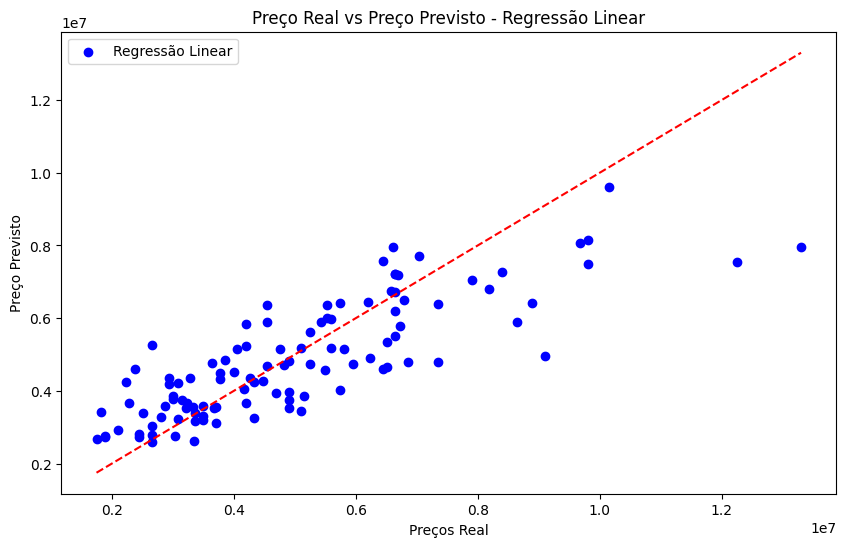

In [14]:
# Gerando gráfico de regressão linear
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, color='blue', label='Regressão Linear')
plt.xlabel('Preços Real')
plt.ylabel('Preço Previsto')
plt.title('Preço Real vs Preço Previsto - Regressão Linear')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.legend()
plt.savefig('../imagens/regressao_linear.png')
plt.show()

In [15]:
# Salvando o modelo de regressão linear
joblib.dump(modelo_lr, '../modelo/modelo_regressao_linear.pkl')

['../modelo/modelo_regressao_linear.pkl']